In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import UpROOT.io as io
import UpROOT.config as conf
import UpROOT.physics.delphes as ph
import UpROOT.plotting.delphes as pt
import UpROOT.pipelines.delphes as pl
import UpROOT.fitting.delphes as fi
import UpROOT.delphes_root as dr

In [ ]:
DATASET01 = 'dimuons_50k_10'

In [ ]:
io.load_dataframe(
    branches=io.txt_data("mpmm"),
    dataset=DATASET01,
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\mpmm.txt
Cantidad de ramas: 33
Archivo: MG5_pp_dimuons_50k_10GeV.root
Árbol seleccionado: Delphes
Total de eventos: 50,000 eventos


,Event/Event.CrossSection,Event/Event.CrossSectionError,Event/Event.Number,Event/Event.Weight,Jet/Jet.BTag,Jet/Jet.Charge,Jet/Jet.ChargedEnergyFraction,Jet/Jet.Constituents,Jet/Jet.Eta,Jet/Jet.Mass,...,Muon/Muon.IsolationVarRhoCorr,Muon/Muon.PT,Muon/Muon.Particle,Muon/Muon.Phi,Muon/Muon.SumPt,Muon/Muon.SumPtCharged,Muon/Muon.SumPtChargedPU,Muon/Muon.SumPtNeutral,Muon/Muon.T,Muon_size
0,[4.662599086761475],[58282.4921875],[0],[32148.173828125],[],[],[],[],[],[],...,"[0.0, 0.0]","[3.087568998336792, 0.8477934002876282]","[{'ref': 15}, {'ref': 16}]","[-1.7241649627685547, 0.13760624825954437]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[5.241671097167e-09, 1.1260561372239408e-08]",2
1,[9.32519817352295],[0.0],[1],[38271.0703125],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],0
2,[13.987797737121582],[0.0003712996549438685],[2],[8473.71484375],[],[],[],[],[],[],...,"[0.0, 0.0]","[3.264291286468506, 1.962198257446289]","[{'ref': 48}, {'ref': 49}]","[2.7701706886291504, -0.08974845707416534]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[6.046352751809536e-09, 5.193854235585604e-09]",2
3,[18.6503963470459],[0.0],[3],[31079.888671875],[],[],[],[],[],[],...,[0.0],[1.8868253231048584],[{'ref': 121}],[0.9523929953575134],[0.0],[0.0],[0.0],[0.0],[6.9213417219771145e-09],1
4,[23.31299591064453],[0.0],[4],[37445.765625],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],0


In [ ]:
output = dr.convert_dataset(
    dataset=DATASET01,
    collections=('EFlowTrack', 'Electron', 'Event', 'Jet', 'Muon', 'Particle', 'Photon', 'ScalarHT', 'Track','Weight'),
    step_size='20 MB',
    object_registry=True,
    overwrite=True
)

Ramas internas de ROOT excluidas:
 - EFlowNeutralHadron/EFlowNeutralHadron.fBits
 - EFlowPhoton/EFlowPhoton.fBits
 - EFlowTrack/EFlowTrack.fBits
 - Electron/Electron.fBits
 - Event/Event.fBits
 - FatJet/FatJet.fBits
 - GenJet/GenJet.fBits
 - GenMissingET/GenMissingET.fBits
 - Jet/Jet.fBits
 - MissingET/MissingET.fBits
 - Muon/Muon.fBits
 - Particle/Particle.fBits
 - Photon/Photon.fBits
 - ScalarHT/ScalarHT.fBits
 - Tower/Tower.fBits
 - Track/Track.fBits
 - Weight/Weight.fBits

Archivo de entrada: C:\Users\mario\Documents\PF\data\MG5_pp_dimuons_50k_10GeV.root
Eventos: 50,000
Colecciones: EFlowTrack, Electron, Jet, Muon, Particle, Photon, ScalarHT, Track, Weight
 EFlowTracks: 54 ramas; bloques de 20 MB
 Electrons: 18 ramas; bloques de 20 MB
 Jets: 46 ramas; bloques de 20 MB
 Muons: 17 ramas; bloques de 20 MB
 Particles: 23 ramas; bloques de 20 MB
 Photons: 15 ramas; bloques de 20 MB
 ScalarHT: 2 ramas; bloques de 20 MB
 Tracks: 54 ramas; bloques de 20 MB
 Weights: 2 ramas; bloques de 20 

In [ ]:
PDATASET01 = 'dimuons_50k_10_p'

In [25]:
cut = '(Eta < 5.0) & (Eta > 2)'

In [ ]:
df_events = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Events'
)
df_events.head()

Archivo: dimuons_50k_10_pandas.root
Árbol seleccionado: Events
Total de eventos: 100,000 eventos


,source_file_id,event_id,source_entry,root_uid,event_number,ReadTime,ProcTime,ProcessID,MPI,event_weight,...,PDF2,n_EFlowTrack,n_Electron,n_Jet,n_Muon,n_Particle,n_Photon,n_ScalarHT,n_Track,n_Weight
0,0,0,0,0,0,0.023200,0.000629,9999,-1,32148.173828,...,0.0,4,0,0,2,87,0,1,4,292
1,0,1,1,0,1,0.000282,0.000311,9999,-1,38271.070312,...,0.0,1,0,0,0,108,0,1,1,292
2,0,2,2,0,2,0.000411,0.000943,9999,-1,8473.714844,...,0.0,6,0,0,2,172,0,1,6,292
3,0,3,3,0,3,0.001040,0.001441,9999,-1,31079.888672,...,0.0,7,0,0,1,424,0,1,7,292
4,0,4,4,0,4,0.000930,0.001048,9999,-1,37445.765625,...,0.0,11,0,0,0,450,0,1,11,292


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\delphes_event_multiplicities.png.


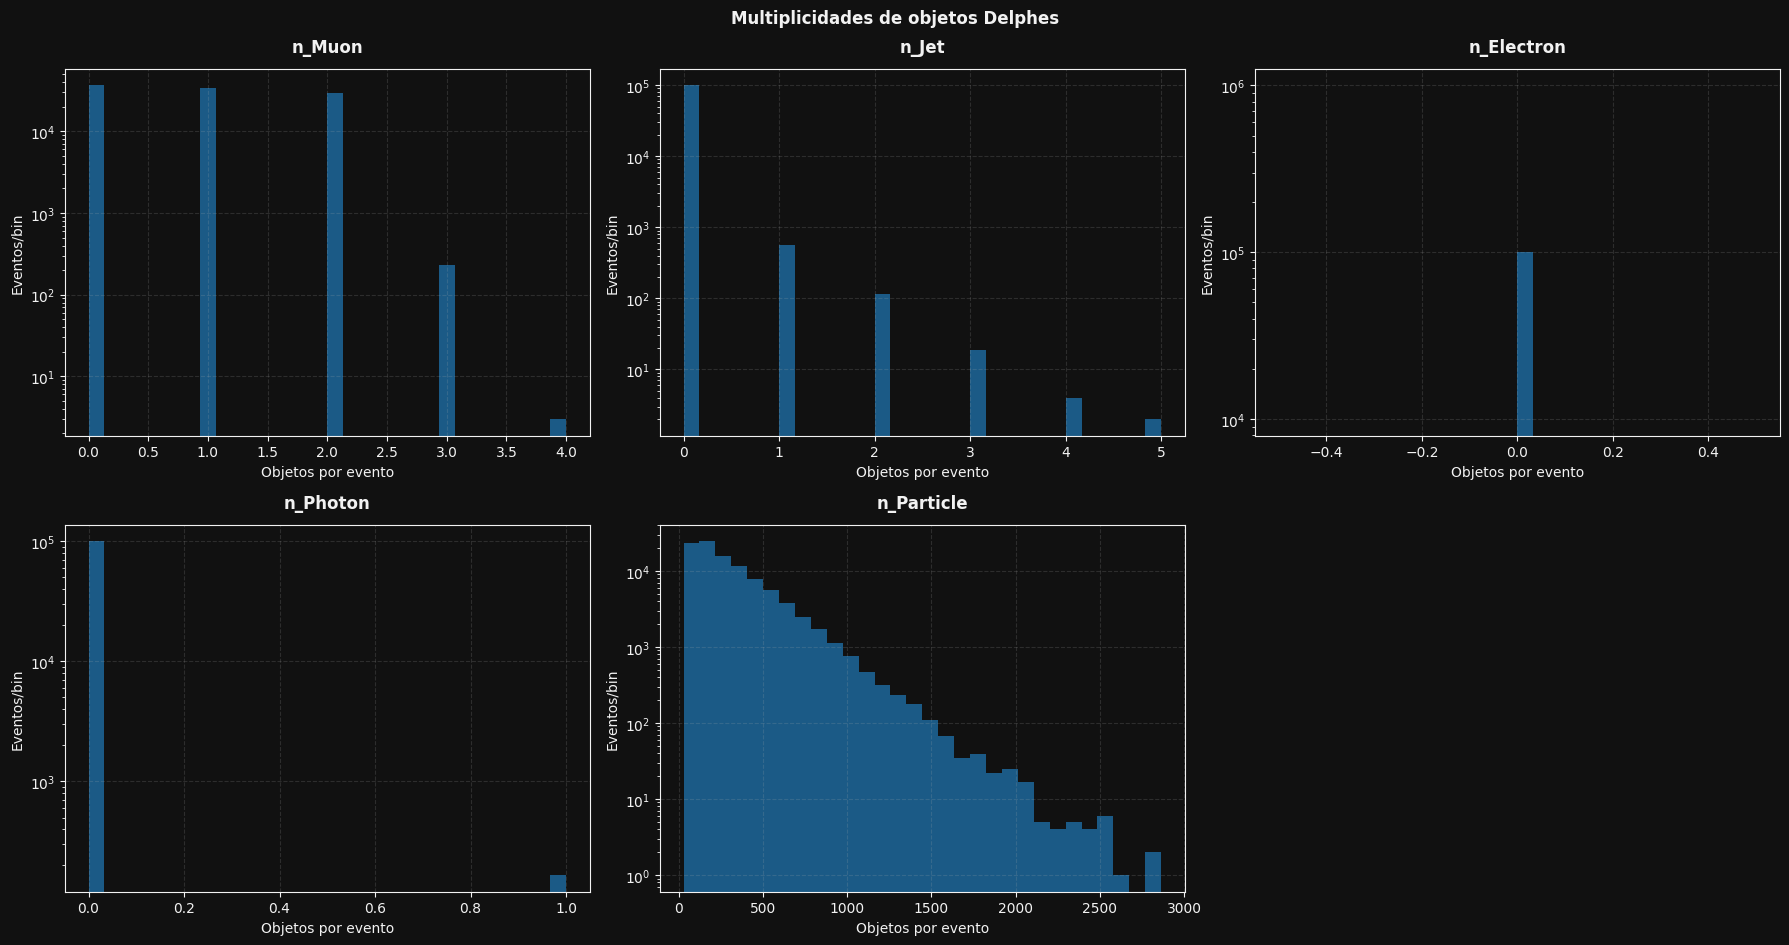

(<Figure size 1800x960 with 6 Axes>,
 array([[<Axes: title={'center': 'n_Muon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Jet'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Electron'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>],
        [<Axes: title={'center': 'n_Photon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Particle'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: >]], dtype=object))

In [ ]:
pt.plot_event_multiplicities(
    df_events, 
    data='delphes03', 
    save=True
)

In [ ]:
df_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons'
)
df_muons.head(7)

Archivo: dimuons_50k_10_pandas.root
Árbol seleccionado: Muons
Total de eventos: 93,412 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
0,0,0,0,0,134,3.087569,0.630984,-1.724165,5.241671e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
1,0,0,0,1,135,0.847793,1.422691,0.137606,1.126056e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
2,0,2,2,0,248,3.264291,0.860358,2.770171,6.046353e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
3,0,2,2,1,249,1.962198,0.585379,-0.089748,5.193854e-09,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-1.478177e-14,0.0,0.0
4,0,3,3,0,590,1.886825,-1.020117,0.952393,6.921342e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
5,0,5,5,0,519,1.810072,1.946156,-0.586551,1.042486e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.000000e+00,0.0,0.0
6,0,6,6,0,183,0.657287,-2.119007,-2.695809,1.030703e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0


In [ ]:
cdf_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons',
    cut=cut
)
cdf_muons.head(7)

Archivo: dimuons_50k_10_pandas.root
Árbol seleccionado: Muons
Total de eventos: 8,720 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
26,0,28,28,0,162,2.330408,2.377219,2.707374,1.018118e-08,-1,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
32,0,31,31,0,236,2.025039,2.009088,3.129760,1.037439e-08,-1,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
52,0,53,53,0,952,4.254420,2.385327,2.266195,1.017809e-08,-1,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
58,0,61,61,0,587,1.003239,2.358147,2.877214,1.018962e-08,1,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
65,0,67,67,0,1164,2.157889,2.293662,0.133919,1.021329e-08,-1,...,0.169656,0.169656,0.366099,0.0,0.0,0.366099,0.0,0.0,0.0,0.0
68,0,69,69,0,265,4.191592,2.447947,-1.826873,1.015779e-08,-1,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
75,0,80,80,0,538,0.580001,2.210477,1.359345,1.025877e-08,-1,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_01.png.


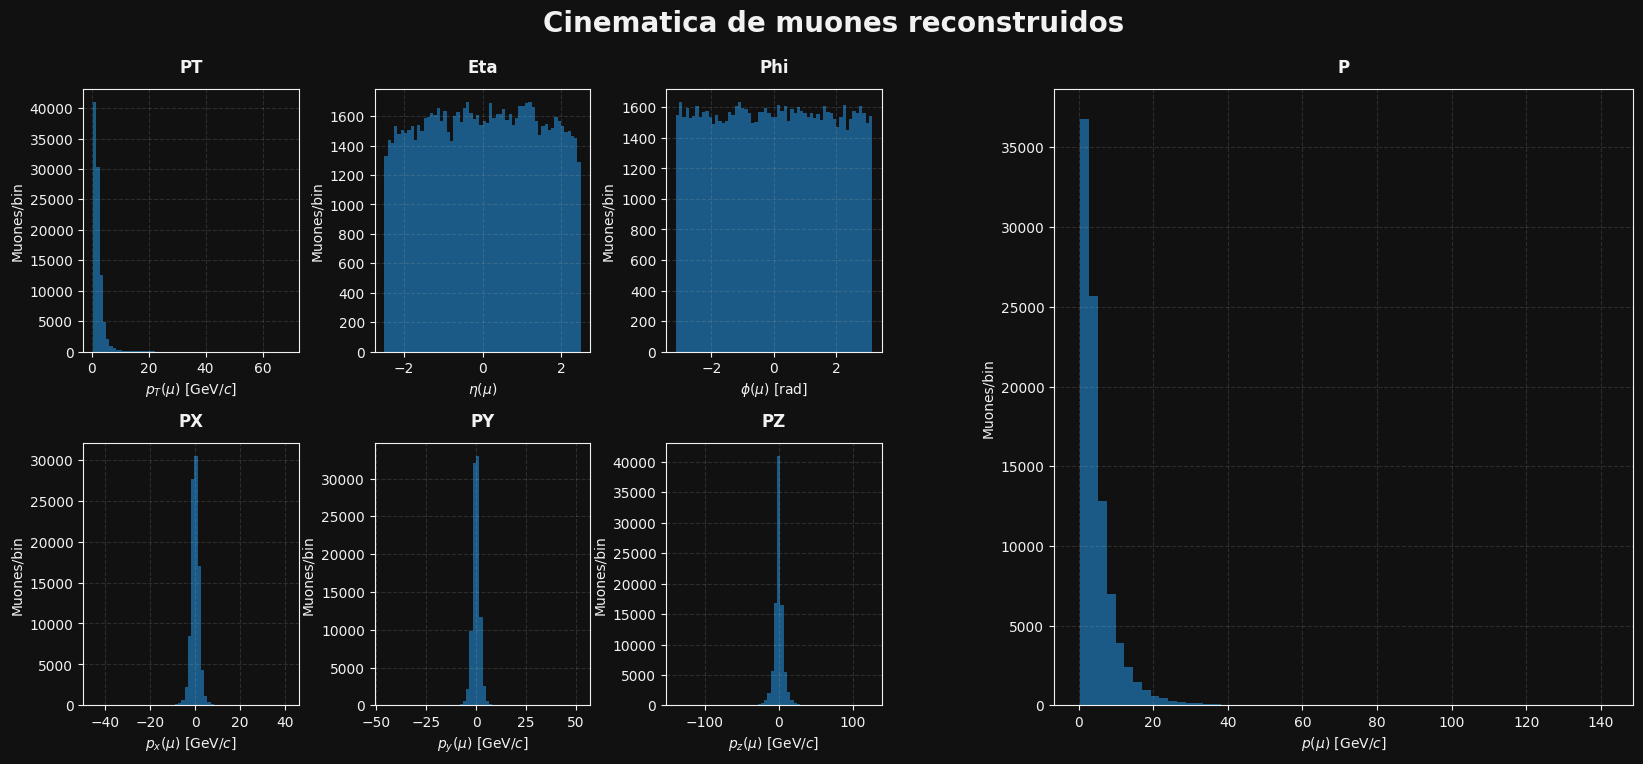

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_01"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_01_cut.png.


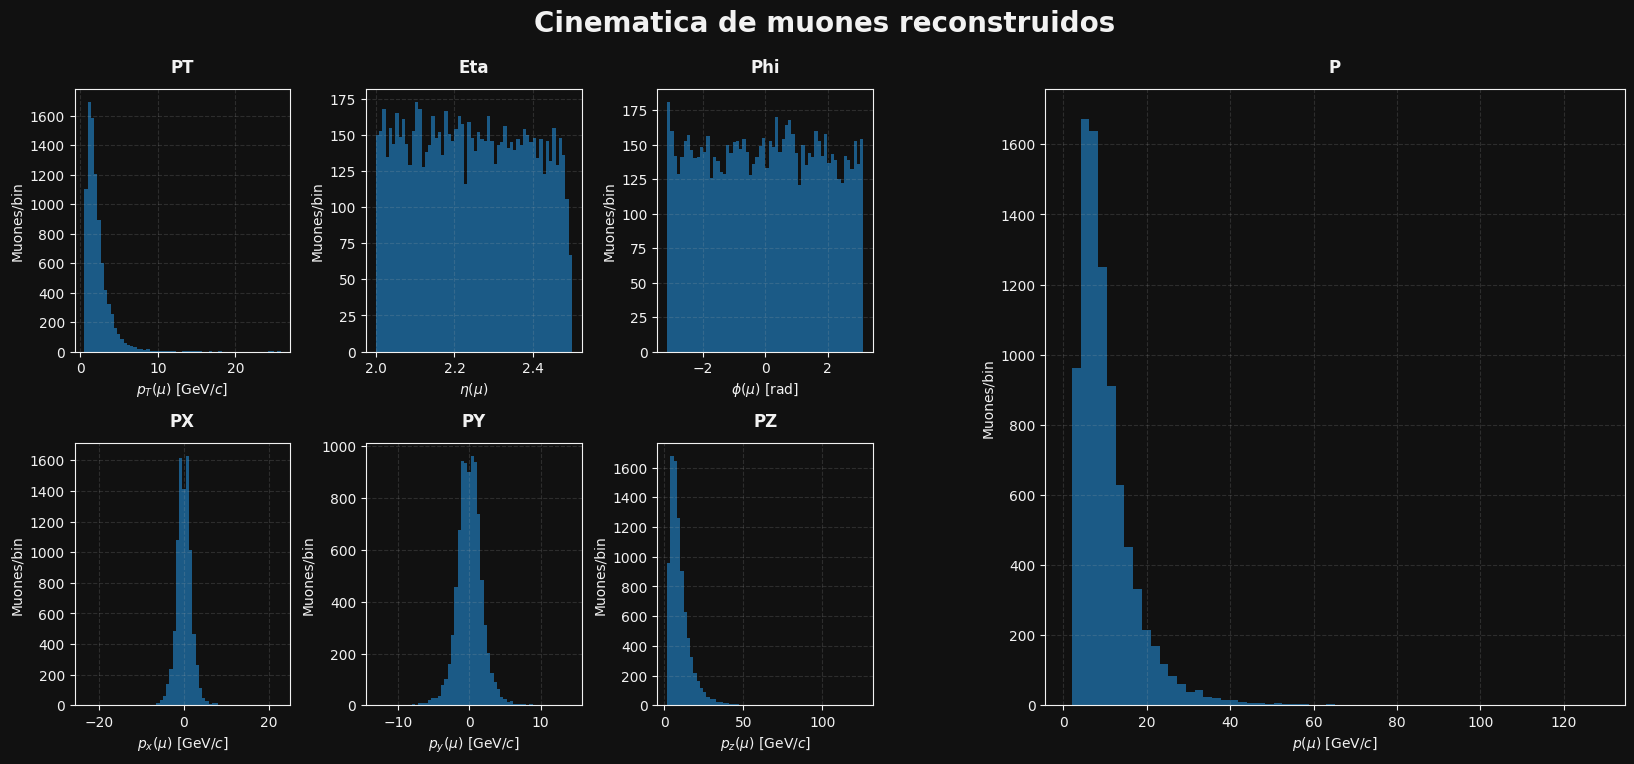

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_01_cut"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_02.png.


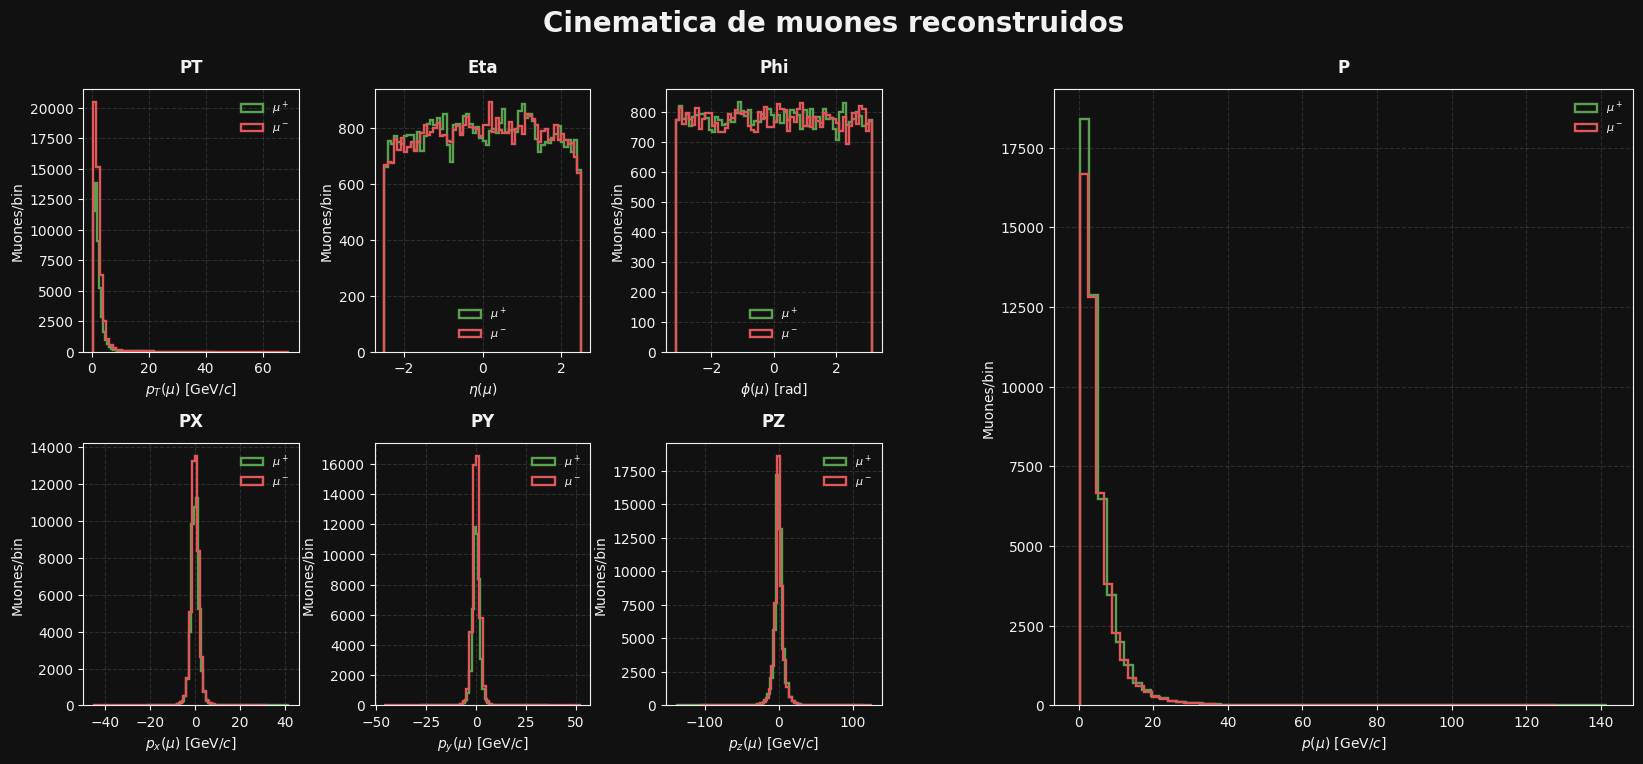

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_02"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_02_cut.png.


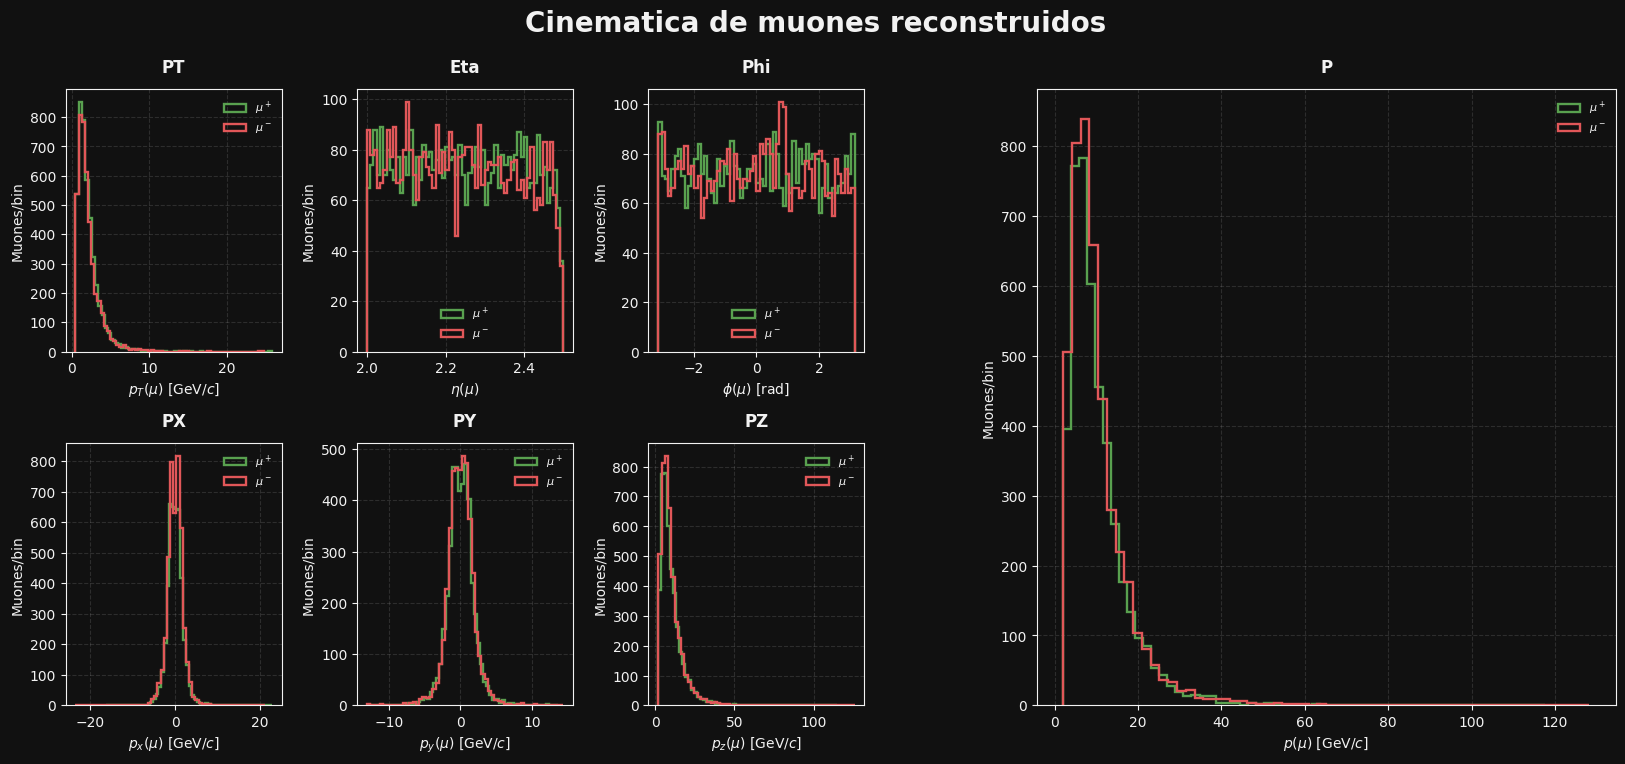

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_02_cut"
)

In [ ]:
df_muons = ph.calc_four_momentum(df_muons)
df_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
0,0,0,0,0,134,3.087569,0.630984,-1.724165,5.241671e-09,1,...,0.0,0.0,0.000000e+00,0.0,0.0,-0.471682,-3.051327,2.080081,3.722878,3.724377
1,0,0,0,1,135,0.847793,1.422691,0.137606,1.126056e-08,-1,...,0.0,0.0,0.000000e+00,0.0,0.0,0.839779,0.116294,1.656250,1.860623,1.863621
2,0,2,2,0,248,3.264291,0.860358,2.770171,6.046353e-09,1,...,0.0,0.0,0.000000e+00,0.0,0.0,-3.041706,1.184744,3.167988,4.548818,4.550045
3,0,2,2,1,249,1.962198,0.585379,-0.089748,5.193854e-09,-1,...,0.0,-0.0,-1.478177e-14,0.0,0.0,1.954301,-0.175868,1.215362,2.308100,2.310517
4,0,3,3,0,590,1.886825,-1.020117,0.952393,6.921342e-09,1,...,0.0,0.0,0.000000e+00,0.0,0.0,1.093859,1.537395,-2.276424,2.956724,2.958611


In [ ]:
cdf_muons = ph.calc_four_momentum(cdf_muons)
cdf_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
26,0,28,28,0,162,2.330408,2.377219,2.707374,1.018118e-08,-1,...,0.000000,0.0,0.0,0.0,0.0,-2.114144,0.980406,12.446809,12.663090,12.663531
32,0,31,31,0,236,2.025039,2.009088,3.129760,1.037439e-08,-1,...,0.000000,0.0,0.0,0.0,0.0,-2.024897,0.023961,7.414072,7.685652,7.686378
52,0,53,53,0,952,4.254420,2.385327,2.266195,1.017809e-08,-1,...,0.000000,0.0,0.0,0.0,0.0,-2.725771,3.266537,22.911237,23.302894,23.303133
58,0,61,61,0,587,1.003239,2.358147,2.877214,1.018962e-08,1,...,0.000000,0.0,0.0,0.0,0.0,-0.968381,0.262156,5.255341,5.350242,5.351286
65,0,67,67,0,1164,2.157889,2.293662,0.133919,1.021329e-08,-1,...,0.366099,0.0,0.0,0.0,0.0,2.138568,0.288119,10.584739,10.802462,10.802979


In [ ]:
df_dimuons = ph.prepare_dimuon_analysis(df_muons, events=df_events)
df_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_charge,dimuon_mass2,muon_sum_pt,pt_balance,acoplanarity,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,displacement_category
0,0,0,134,3.087569,0.630984,-1.724165,5.241671e-09,1,15,0.0,...,0,8.515629,3.935362,0.569141,1.279822,0.808270,0.376395,NaN,NaN,mixed
1,2,0,248,3.264291,0.860358,2.770171,6.046353e-09,1,48,0.0,...,0,25.653276,5.226490,0.249133,0.281674,0.756347,-0.136630,NaN,NaN,mixed
2,11,0,423,1.745479,0.605530,-1.338449,5.289926e-09,1,50,0.0,...,0,7.532716,2.817626,0.238971,0.068486,0.630162,0.034510,NaN,NaN,mixed
3,14,1,200,1.402946,-2.127385,1.868997,1.029679e-08,1,23,0.0,...,0,41.991750,6.620345,0.576171,1.048331,-0.988830,0.637087,NaN,NaN,mixed
4,17,1,1219,1.009535,-1.489425,0.482975,1.109065e-08,1,273,0.0,...,0,9.064182,2.362089,0.145218,0.379294,-0.640353,0.637949,NaN,NaN,mixed
5,18,1,380,1.499504,-2.417985,2.493192,1.016788e-08,1,44,0.0,...,0,34.310188,4.011139,0.252330,0.605011,-1.228502,0.759390,NaN,NaN,mixed
6,20,0,283,4.272577,1.686740,-0.073409,1.071759e-08,1,35,0.0,...,0,51.578638,6.348946,0.345917,0.084554,1.251294,-0.558339,NaN,NaN,mixed


In [ ]:
cdf_dimuons = ph.prepare_dimuon_analysis(cdf_muons, events=df_events)
cdf_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_charge,dimuon_mass2,muon_sum_pt,pt_balance,acoplanarity,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,displacement_category
0,474,1,196,1.755346,2.187724,-0.738276,1.026282e-08,1,15,0.00000,...,0,12.287782,5.032753,0.302431,1.509953,2.235217,0.037195,NaN,NaN,mixed
1,792,1,128,0.952030,2.197023,-0.317297,1.026011e-08,1,15,0.00000,...,0,5.699653,2.438336,0.219115,0.194722,2.300390,0.087880,NaN,NaN,mixed
2,1404,1,650,2.428802,2.170750,-1.013824,1.027134e-08,1,106,0.00000,...,0,13.642234,4.961697,0.020980,1.472450,2.229980,0.058816,NaN,NaN,mixed
3,1572,1,1305,1.509312,2.214699,-2.055708,1.024962e-08,1,287,0.22189,...,0,11.993084,3.658821,0.174973,0.571598,2.224234,0.009548,NaN,NaN,mixed
4,1954,1,152,1.926749,2.345197,1.835679,1.019290e-08,1,15,0.00000,...,0,9.855915,4.065695,0.052192,1.382069,2.382408,0.036618,NaN,NaN,mixed
5,2081,0,491,10.662640,2.030789,1.997989,1.035767e-08,1,123,0.00000,...,0,8.431191,16.635908,0.281882,2.795113,2.071299,0.056443,NaN,NaN,mixed
6,2115,1,282,2.126539,2.214267,0.775683,1.024920e-08,1,38,0.00000,...,0,22.751069,5.480907,0.224019,0.944568,2.149903,-0.051938,NaN,NaN,mixed


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\dimuon_mass_01.png.


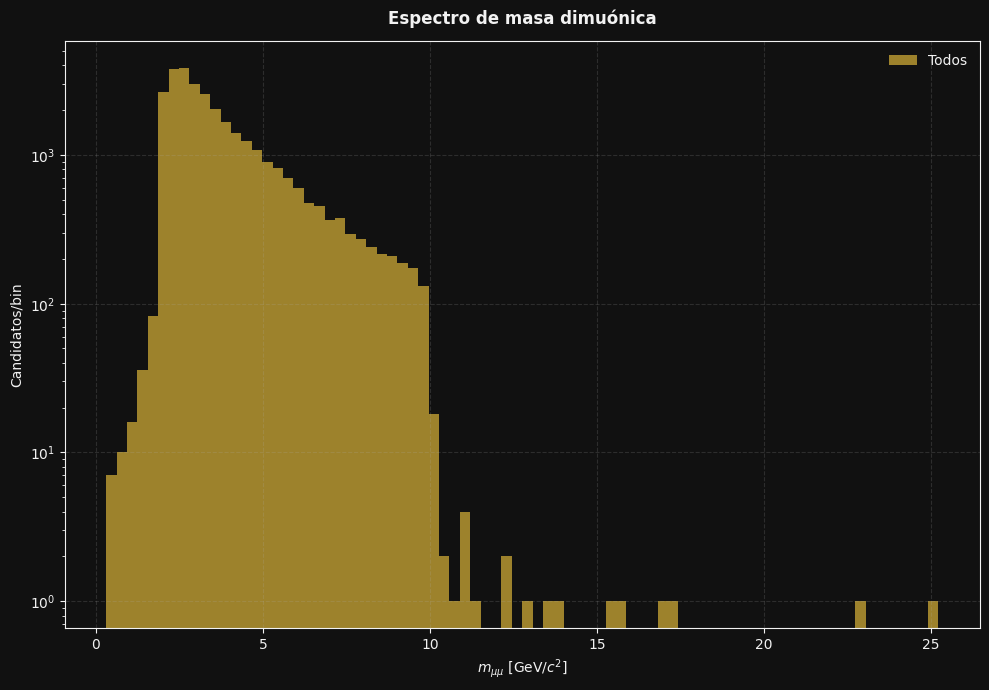

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [ ]:
pt.plot_dimuon_mass(
    df_dimuons, 
    bins=80, 
    save=True, 
    log_y=True, 
    data='delphes03', 
    filename="dimuon_mass_01"
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\dimuon_mass_01_cut.png.


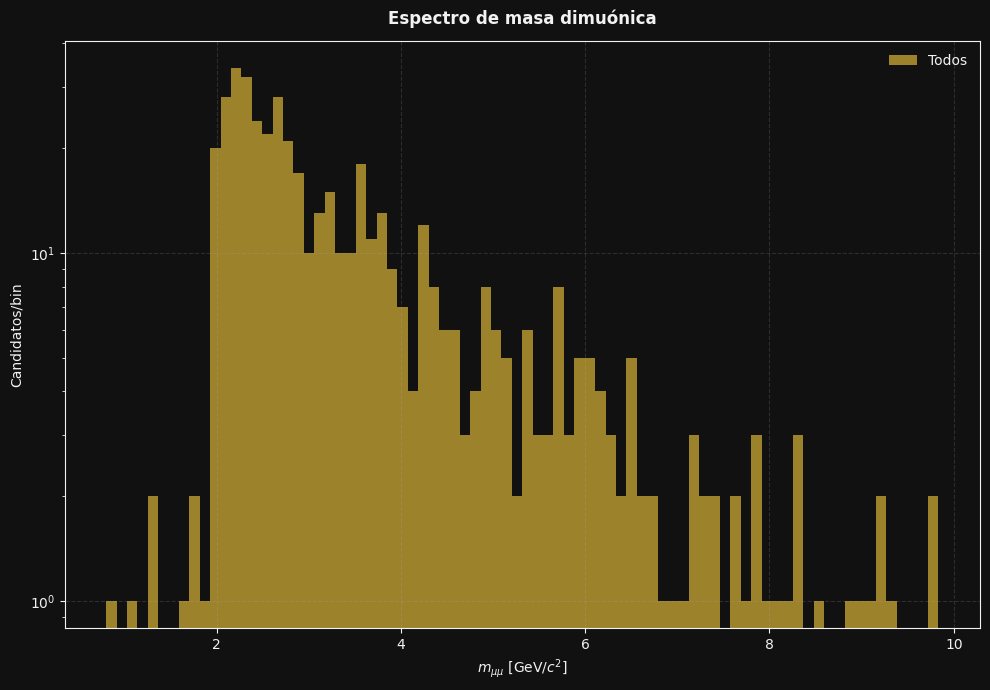

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [ ]:
pt.plot_dimuon_mass(
    cdf_dimuons, 
    bins=80, 
    save=True, 
    log_y=True, 
    data='delphes03', 
    filename="dimuon_mass_01_cut"
)